<a href="https://colab.research.google.com/github/shanikagalaudage/includeher_paper/blob/main/PlotsTables.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notes
Note this notebook was originally created for the IncludeHer paper, Invisible women: Gender representation in high school science courses across Australia, Ross et al., 2023 (kathryn.ross@curtin.edu.au) which can be found here: https://journals.sagepub.com/doi/full/10.1177/00049441231197245

The notebook has now been modified by Greg Cooke (gjc53@cam.ac.uk) to investigate similar statistics for UK syllabi for 14-16 year olds (GCSE) and 16-18 year olds (A-Level)

# UK A-Level Analysis

In [26]:
# Imports
import numpy as np
import json

from matplotlib import rcParams
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt

# Set plot formatting
rcParams["legend.framealpha"]=0.5
rcParams["legend.frameon"]=True
rcParams["legend.edgecolor"]="white"
rcParams["axes.labelsize"]=14
rcParams["axes.grid"] = True
rcParams["grid.color"] = "black"
rcParams["grid.linewidth"] = 1.0
rcParams["grid.linestyle"] = "--"
rcParams["grid.alpha"] = 0.2

rcParams["xtick.labelsize"]=20
rcParams["ytick.labelsize"]=20
rcParams["legend.fontsize"]=22
rcParams["axes.labelsize"]=22
rcParams["axes.titlesize"]=22


colours = ["#3E284F", "#AB7AD1", "#024963", "#3D9CB3","#C7639D", "#FAA7CB", "#FFEDF7", "#663351"]
colours = ["#1c579e", "#1c9e79", "#024963", "#3D9CB3","#C7639D", "#FAA7CB", "#FFEDF7", "#663351"]

# Create JSON files

In [27]:
import json

import json

# Exam boards (these really are global, so keep them explicit)
exam_boards = ["AQA", "CCEA", "Edexcel", "OCR", "Scottish highers", "WJEC"]

EXAMBOARDS = {
    "AQA": "AQA",
    "CCEA": "CCEA",
    "Edexcel": "Edexcel",
    "OCR": "OCR",
    "Scottish highers": "Scottish_highers",
    "WJEC": "WJEC",
}

# Read in the JSON files
dataset = {}
for board in exam_boards:
    path = f"../Stats/{EXAMBOARDS[board]}_SummaryStats_A_Level.json"
    with open(path, "r", encoding="utf-8") as ff:
        dataset[EXAMBOARDS[board]] = json.load(ff)




In [28]:
# ------------------------------------------------------------
# Create a json data file with all statistics (robust version)
# ------------------------------------------------------------
subjects = {"physics", "chemistry", "biology", "environmental science", "geology", "astronomy"}
Exam_Boards = ["AQA", "CCEA", "Edexcel", "OCR", "Scottish_highers", "WJEC"]
exam_boards = ["AQA", "CCEA", "Edexcel", "OCR", "Scottish highers", "WJEC"]
categories = ["concept", "scientist"]


def get_counts(board, subject, category):
    """Return (male, female) counts or (0, 0) if missing."""
    subj = dataset[EXAMBOARDS[board]]["subjects"].get(subject)
    if subj is None:
        return 0, 0
    cat = subj.get(category)
    if cat is None:
        return 0, 0
    return cat["male"], cat["female"]


stats_data = {}

# ------------------------------------------------------------
# Per-subject / per-category / per-board statistics
# ------------------------------------------------------------

for sb in subjects:
    stats_data[sb] = {}
    for cat in categories:
        stats_data[sb][cat] = {}
        for eb in exam_boards:
            m, f = get_counts(eb, sb, cat)
            stats_data[sb][cat][eb] = {
                "male": m,
                "female": f,
                "both": m + f
            }

# ------------------------------------------------------------
# OVERALL SECTION
# ------------------------------------------------------------

stats_data["overall"] = {
    "subjects": {},
    "exam_boards": {}
}

tot_across_boards_categories_subjects = 0
tot_across_boards_concept_subjects = 0
tot_across_boards_scientist_subjects = 0

# ------------------------------------------------------------
# Overall by subject
# ------------------------------------------------------------

for sb in subjects:
    stats_data["overall"]["subjects"][sb] = {}
    subject_total = 0

    for cat in categories:
        cat_total = sum(
            stats_data[sb][cat][eb]["both"]
            for eb in exam_boards
        )
        stats_data["overall"]["subjects"][sb][cat] = cat_total
        subject_total += cat_total

    stats_data["overall"]["subjects"][sb]["total"] = subject_total

    tot_across_boards_concept_subjects += stats_data["overall"]["subjects"][sb].get("concept", 0)
    tot_across_boards_scientist_subjects += stats_data["overall"]["subjects"][sb].get("scientist", 0)
    tot_across_boards_categories_subjects += subject_total


for sb in subjects:
    stats_data["overall"]["subjects"][sb]["% of total mentions"] = round(
        stats_data["overall"]["subjects"][sb]["total"]
        / tot_across_boards_categories_subjects * 100, 2
    )
    stats_data["overall"]["subjects"][sb]["% of total concept mentions"] = round(
        stats_data["overall"]["subjects"][sb].get("concept", 0)
        / tot_across_boards_concept_subjects * 100, 2
    )
    stats_data["overall"]["subjects"][sb]["% of total scientist mentions"] = round(
        stats_data["overall"]["subjects"][sb].get("scientist", 0)
        / tot_across_boards_scientist_subjects * 100, 2
    )

# ------------------------------------------------------------
# Overall by exam board
# ------------------------------------------------------------

tot_across_subjects_categories_boards = 0
tot_across_subjects_concept_boards = 0
tot_across_subjects_scientist_boards = 0

for eb in exam_boards:
    stats_data["overall"]["exam_boards"][eb] = {}
    board_total = 0

    for cat in categories:
        cat_total = sum(
            stats_data[sb][cat][eb]["both"]
            for sb in subjects
        )
        stats_data["overall"]["exam_boards"][eb][cat] = cat_total
        board_total += cat_total

    stats_data["overall"]["exam_boards"][eb]["total"] = board_total

    tot_across_subjects_concept_boards += stats_data["overall"]["exam_boards"][eb].get("concept", 0)
    tot_across_subjects_scientist_boards += stats_data["overall"]["exam_boards"][eb].get("scientist", 0)
    tot_across_subjects_categories_boards += board_total


for eb in exam_boards:
    stats_data["overall"]["exam_boards"][eb]["% of total mentions"] = round(
        stats_data["overall"]["exam_boards"][eb]["total"]
        / tot_across_subjects_categories_boards * 100, 2
    )
    stats_data["overall"]["exam_boards"][eb]["% of total concept mentions"] = round(
        stats_data["overall"]["exam_boards"][eb].get("concept", 0)
        / tot_across_subjects_concept_boards * 100, 2
    )
    stats_data["overall"]["exam_boards"][eb]["% of total scientist mentions"] = round(
        stats_data["overall"]["exam_boards"][eb].get("scientist", 0)
        / tot_across_subjects_scientist_boards * 100, 2
    )

# ------------------------------------------------------------
# Top-level totals
# ------------------------------------------------------------

stats_data["overall"]["total mentions"] = tot_across_boards_categories_subjects
stats_data["overall"]["total concept mentions"] = tot_across_boards_concept_subjects
stats_data["overall"]["total scientist mentions"] = tot_across_boards_scientist_subjects

# ------------------------------------------------------------
# Write out
# ------------------------------------------------------------

with open('../Stats/FullSummaryStatsUK_A_Level.json', 'w', encoding="utf-8") as fp:
    json.dump(stats_data, fp, indent=4)


# Unique scientist count

In [29]:
import json
from collections import Counter, defaultdict

# ============================================================
# 1. Containers
# ============================================================

# Unique scientists across all exam boards (deduplicated by name)
global_scientists = {}

# Scientist- and concept-category mentions
scientist_mentions_by_board = defaultdict(int)
concept_mentions_by_board = defaultdict(int)

scientist_mentions_by_board_subject = defaultdict(lambda: defaultdict(int))
concept_mentions_by_board_subject = defaultdict(lambda: defaultdict(int))

# ============================================================
# 2. Parse all exam boards
# ============================================================

for board in Exam_Boards:
    path = f"../Stats/{board}_SummaryStats_A_Level.json"

    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    # ---- Count mentions by subject ----
    for subject, subject_data in data["subjects"].items():

        sci = subject_data.get("scientist", {})
        con = subject_data.get("concept", {})

        sci_mentions = sci.get("male", 0) + sci.get("female", 0)
        con_mentions = con.get("male", 0) + con.get("female", 0)

        scientist_mentions_by_board_subject[board][subject] += sci_mentions
        concept_mentions_by_board_subject[board][subject] += con_mentions

        scientist_mentions_by_board[board] += sci_mentions
        concept_mentions_by_board[board] += con_mentions

    # ---- Merge unique scientists (identity only, no category meaning) ----
    for name, info in data["names"].items():
        if name not in global_scientists:
            global_scientists[name] = {
                "gender": info.get("gender", "unknown"),
                "region": info.get("region", "unknown")
            }

# ============================================================
# 3. Global totals (correct semantics)
# ============================================================

total_unique_scientists = len(global_scientists)

total_scientist_mentions_global = sum(scientist_mentions_by_board.values())
total_concept_mentions_global = sum(concept_mentions_by_board.values())

unique_by_gender = Counter(
    s["gender"] for s in global_scientists.values()
)

unique_by_region = Counter(
    s["region"] for s in global_scientists.values()
)

# ============================================================
# 4. Reporting
# ============================================================

print("\n=== UNIQUE SCIENTISTS (GLOBAL, DEDUPLICATED ACROSS ALL EXAM BOARDS) ===")
print(f"Total unique scientists (distinct named individuals): {total_unique_scientists}")
print(f"Unique scientists by gender: {dict(unique_by_gender)}")
print(f"Unique scientists by region: {dict(unique_by_region)}")

print("\n=== TOTAL SCIENTIST-CATEGORY MENTIONS PER EXAM BOARD ===")
for board in Exam_Boards:
    print(f"{board}: {scientist_mentions_by_board[board]} scientist-category mentions")

print("\n=== TOTAL CONCEPT-CATEGORY MENTIONS PER EXAM BOARD ===")
for board in Exam_Boards:
    print(f"{board}: {concept_mentions_by_board[board]} concept-category mentions")

print("\n=== TOTAL SCIENTIST-CATEGORY MENTIONS PER EXAM BOARD AND SUBJECT ===")
for board in Exam_Boards:
    print(f"\n{board}:")
    for subject, count in scientist_mentions_by_board_subject[board].items():
        print(f"  {subject}: {count} scientist-category mentions")

print("\n=== TOTAL CONCEPT-CATEGORY MENTIONS PER EXAM BOARD AND SUBJECT ===")
for board in Exam_Boards:
    print(f"\n{board}:")
    for subject, count in concept_mentions_by_board_subject[board].items():
        print(f"  {subject}: {count} concept-category mentions")

print("\n=== GLOBAL TOTALS ACROSS ALL EXAM BOARDS ===")
print(
    "Total scientist-category mentions across all exam boards "
    f"(counting repeated mentions): {total_scientist_mentions_global}"
)
print(
    "Total concept-category mentions across all exam boards "
    f"(counting repeated mentions): {total_concept_mentions_global}"
)

# ============================================================
# 5. Consistency check (now valid)
# ============================================================

total_mentions_from_files = 0

for board in Exam_Boards:
    path = f"../Stats/{board}_SummaryStats_A_Level.json"

    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    sci = data["overall"]["scientist"]
    total_mentions_from_files += sci.get("male", 0) + sci.get("female", 0)

print("\n=== CONSISTENCY CHECK (SCIENTIST-CATEGORY MENTIONS) ===")
print(
    f"Total scientist-category mentions from per-board 'overall' sections: "
    f"{total_mentions_from_files}"
)
print(
    f"Total scientist-category mentions summed from subjects: "
    f"{total_scientist_mentions_global}"
)

if total_scientist_mentions_global == total_mentions_from_files:
    print("✔ Totals match — scientist-category aggregation is correct.")
else:
    print("✘ Totals do NOT match — investigate upstream counting.")


print("\n=== UNIQUE SCIENTIST NAMES (DEDUPLICATED ACROSS ALL EXAM BOARDS) ===")
for name in sorted(global_scientists.keys()):
    print(name)



=== UNIQUE SCIENTISTS (GLOBAL, DEDUPLICATED ACROSS ALL EXAM BOARDS) ===
Total unique scientists (distinct named individuals): 172
Unique scientists by gender: {'male': 169, 'female': 3}
Unique scientists by region: {'europe': 130, 'north america': 35, 'oceania': 1, 'europe-north america': 4, 'asia-north america': 1, 'oceania-europe': 1}

=== TOTAL SCIENTIST-CATEGORY MENTIONS PER EXAM BOARD ===
AQA: 0 scientist-category mentions
CCEA: 0 scientist-category mentions
Edexcel: 0 scientist-category mentions
OCR: 16 scientist-category mentions
Scottish_highers: 11 scientist-category mentions
WJEC: 4 scientist-category mentions

=== TOTAL CONCEPT-CATEGORY MENTIONS PER EXAM BOARD ===
AQA: 96 concept-category mentions
CCEA: 51 concept-category mentions
Edexcel: 54 concept-category mentions
OCR: 77 concept-category mentions
Scottish_highers: 81 concept-category mentions
WJEC: 76 concept-category mentions

=== TOTAL SCIENTIST-CATEGORY MENTIONS PER EXAM BOARD AND SUBJECT ===

AQA:
  physics: 0 sci

In [30]:
# 1. List called names from existing dictionary
names = list(global_scientists.keys())

# 2. Extract surnames into a dictionary: {surname: full_name}
# We use name.split()[-1] to get the very last word in the string
surname_map = {name.split()[-1]: name for name in names}

# 3. If you just want a simple list of surnames:
last_names_only = [name.split()[-1] for name in names]

# --- Verification ---
print("\nLast names list:", last_names_only)

last_names_only.append('Curie')
last_names_only.append('Lovelace')
last_names_only.append('Meitner')
last_names_only.append('Solomon')
last_names_only.append('Cannon')
last_names_only.append('Rubin')
last_names_only.append('Burnell')
last_names_only.append('Hodgkin')
last_names_only.append('McClintock')
last_names_only.append('Carson')
last_names_only.append('Goodall')
last_names_only.append('Herschel')
last_names_only.append('Leakey')
last_names_only.append('Wu')
last_names_only.append('Anning')
last_names_only.append('Cori')


Last names list: ['rayleigh', 'hipparchus', 'geiger', 'broglie', 'malus', 'huygens', 'newton', 'coulomb', 'young', 'doppler', 'hubble', 'einstein', 'bertozzi', 'planck', 'wien', 'boltzmann', 'hooke', 'avogadro', 'stefan', 'michelson', 'morley', 'faraday', 'lenz', 'snellius', 'ohm', 'boyle', 'charles', 'brown', 'rutherford', 'millikan', 'maxwell', 'thomson', 'schwarzschild', 'balmer', 'hertz', 'fizeau', 'hall', 'zener', 'boole', 'johnson', 'samos', 'russell', 'hertzsprung', 'henle', 'jr.', 'pacini', 'crick', 'watson', 'krebs', 'benedict', 'golgi', 'simpson', 'hardy', 'weinberg', 'purkyn?', 'bohr', 'gosset', 'london', 'hess', 'chatelier', 'fehling', 'tollens', 'haber', 'born', 'brønsted', 'lowry', 'friedel', 'crafts', 'arrhenius', 'gibbs', 'waals', 'cahn', 'ingold', 'prelog', 'nernst', 'lasky', 'lincoln', 'vavilov', 'spearman', 'mann', 'whitney', 'tullgren', 'kepler', 'fleming', 'meselson', 'stahl', 'mendel', 'stokes', 'down', 'turner', 'gram', 'grignard', 'pauling', 'syracuse', 'kirchh

In [ ]:
import PyPDF2
import os
import re
from collections import defaultdict

# 1. List of PDF files to scan
pdf_files = [
    "/Users/gregcooke/IncludeHerUK/Specifications/KS5/AQA_A_Level_Biology.PDF",
    "/Users/gregcooke/IncludeHerUK/Specifications/KS5/AQA_A_Level_Chemistry.PDF",
    "/Users/gregcooke/IncludeHerUK/Specifications/KS5/AQA_A_Level_Physics.PDF",
    "/Users/gregcooke/IncludeHerUK/Specifications/KS5/AQA_A_Level_Environmental_Science.PDF",
    
    "/Users/gregcooke/IncludeHerUK/Specifications/KS5/CCEA_A_Level_Biology.pdf",
    "/Users/gregcooke/IncludeHerUK/Specifications/KS5/CCEA_A_Level_Chemistry.pdf",
    "/Users/gregcooke/IncludeHerUK/Specifications/KS5/CCEA_A_Level_Physics.pdf",
    
    "/Users/gregcooke/IncludeHerUK/Specifications/KS5/WJEC_A_Level_Biology.pdf",
    "/Users/gregcooke/IncludeHerUK/Specifications/KS5/WJEC_A_Level_Chemistry.pdf",
    "/Users/gregcooke/IncludeHerUK/Specifications/KS5/WJEC_A_Level_Physics.pdf",
    "/Users/gregcooke/IncludeHerUK/Specifications/KS5/WJEC_A_Level_Geology.pdf",
    
    "/Users/gregcooke/IncludeHerUK/Specifications/KS5/OCR_A_Level_Biology.pdf",
    "/Users/gregcooke/IncludeHerUK/Specifications/KS5/OCR_A_Level_Chemistry.pdf",
    "/Users/gregcooke/IncludeHerUK/Specifications/KS5/OCR_A_Level_Physics.pdf",
    "/Users/gregcooke/IncludeHerUK/Specifications/KS5/OCR_A_Level_Geology.pdf",
    
    "/Users/gregcooke/IncludeHerUK/Specifications/KS5/Edexcel_A_Level_Biology.pdf",
    "/Users/gregcooke/IncludeHerUK/Specifications/KS5/Edexcel_A_Level_Chemistry.pdf",
    "/Users/gregcooke/IncludeHerUK/Specifications/KS5/Edexcel_A_Level_Physics.pdf",
]

def search_names_in_pdfs(names, files):
    findings = defaultdict(lambda: {"full_matches": [], "surname_matches": []})

    for pdf_path in files:
        print(f"Scanning {pdf_path}...")
        try:
            with open(pdf_path, 'rb') as f:
                reader = PyPDF2.PdfReader(f)
                # Combine all pages into one string for easier searching
                content = " ".join([page.extract_text() for page in reader.pages])
                
                for full_name in last_names_only:
                    # Check for Full Name
                    if full_name.lower() in content.lower():
                        findings[pdf_path]["full_matches"].append(full_name)
                    
                    else:
                        # Extract surname and check for Eponyms (e.g., Newton's Law)
                        surname = full_name.split()[-1]
                        
                        # Use Regex to find the surname as a whole word
                        # \b ensures we don't match 'Darwin' inside 'Darwinism' unless intended
                        pattern = r'\b' + re.escape(surname) + r"(?:'s|s|)\b"
                        
                                
        except Exception as e:
            print(f"Could not read {pdf_path}: {e}")

    return findings

# Execute Search
results = search_names_in_pdfs(last_names_only, pdf_files)

# 4. Reporting the findings
print("\n" + "="*50)
print("PDF SEARCH RESULTS")
print("="*50)

for pdf, data in results.items():
    print(f"\nDOCUMENT: {pdf}")
    print(f"  Names found: {', '.join(data['full_matches']) or 'None'}")
    #for i in range(len(data['full_matches'])):
    #    os.system("grep -r '+data['full_matches']+'")
    #print(f"  Surnames/Eponyms found: {', '.join([n.split()[-1] for n in data['surname_matches']]) or 'None'}")

Scanning /Users/gregcooke/IncludeHerUK/Specifications/KS5/AQA_A_Level_Biology.PDF...
Could not read /Users/gregcooke/IncludeHerUK/Specifications/KS5/AQA_A_Level_Biology.PDF: PyCryptodome is required for AES algorithm
Scanning /Users/gregcooke/IncludeHerUK/Specifications/KS5/AQA_A_Level_Chemistry.PDF...
Could not read /Users/gregcooke/IncludeHerUK/Specifications/KS5/AQA_A_Level_Chemistry.PDF: PyCryptodome is required for AES algorithm
Scanning /Users/gregcooke/IncludeHerUK/Specifications/KS5/AQA_A_Level_Physics.PDF...
Could not read /Users/gregcooke/IncludeHerUK/Specifications/KS5/AQA_A_Level_Physics.PDF: PyCryptodome is required for AES algorithm
Scanning /Users/gregcooke/IncludeHerUK/Specifications/KS5/AQA_A_Level_Environmental_Science.PDF...
Could not read /Users/gregcooke/IncludeHerUK/Specifications/KS5/AQA_A_Level_Environmental_Science.PDF: PyCryptodome is required for AES algorithm
Scanning /Users/gregcooke/IncludeHerUK/Specifications/KS5/CCEA_A_Level_Biology.pdf...


# UK Education Figures

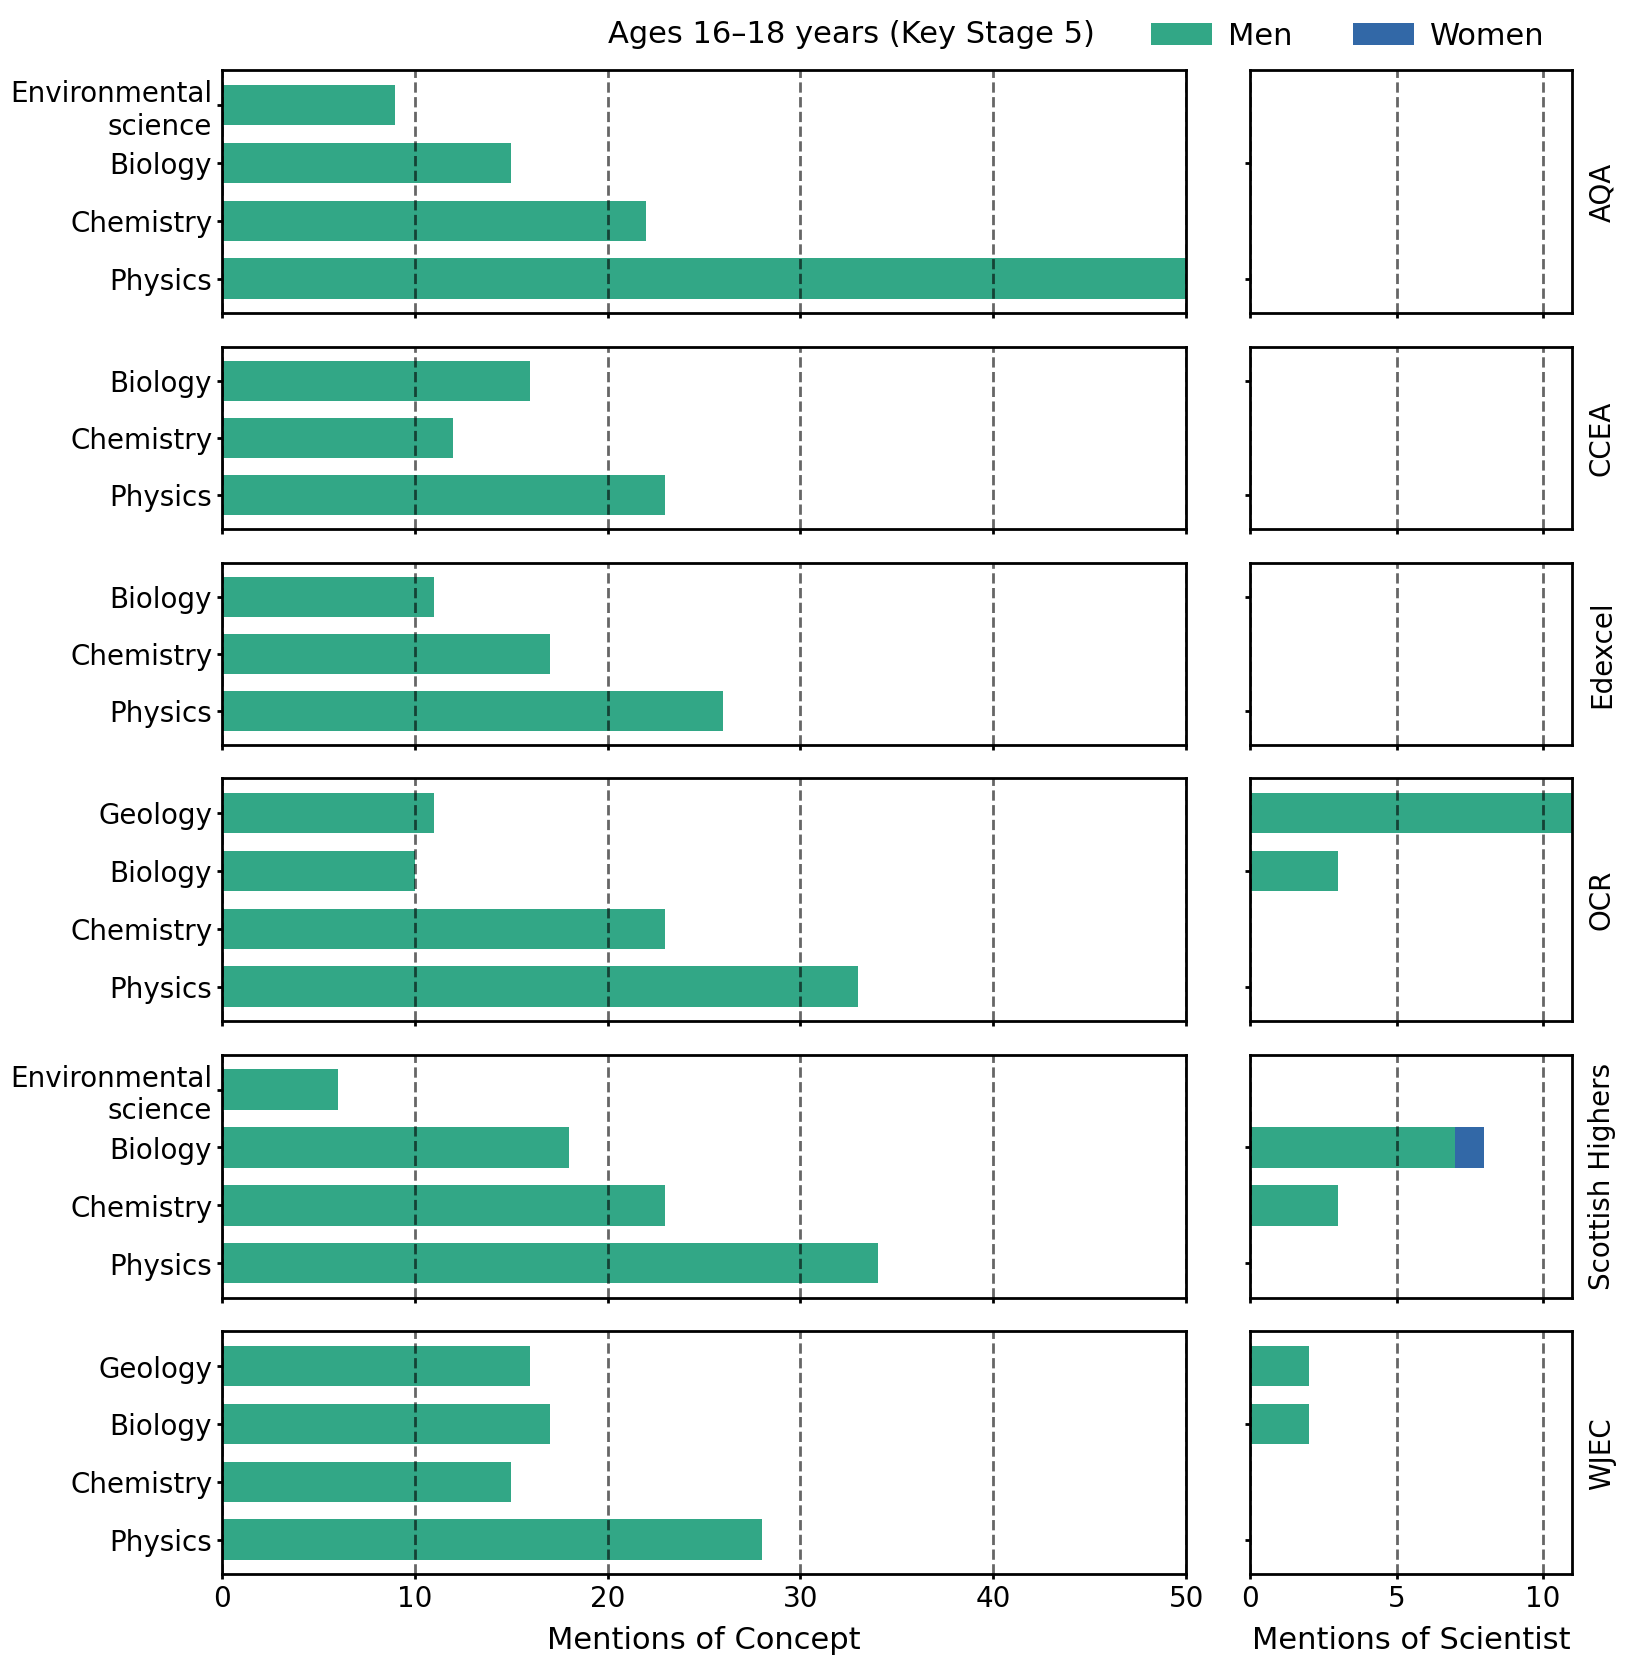

In [32]:
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Global style: Thicker axes and ticks
# ------------------------------------------------------------
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['axes.linewidth'] = 2

# ------------------------------------------------------------
# Setup Data structures
# ------------------------------------------------------------
subject_display_names = {
    "environmental science": "Environmental\nscience",
    "biology": "Biology",
    "physics": "Physics",
    "chemistry": "Chemistry",
    "geology": "Geology",
    "astronomy": "Astronomy",
}

core_subjects = {"Physics", "Chemistry", "Biology"}

# 1. Pre-calculate subjects per board to determine height ratios
subject_counts = []
subjects_by_board = []

for board in exam_boards:
    # Identify subjects that meet the criteria for this board
    subjects_here = [
        sb for sb, data in dataset[EXAMBOARDS[board]]["subjects"].items()
        if (
            sb in core_subjects
            or (
                "concept" in data
                and (data["concept"]["male"] + data["concept"]["female"]) > 0
            )
        )
    ]
    subjects_by_board.append(subjects_here)
    subject_counts.append(len(subjects_here))

# 2. Dynamic Figure Sizing
# Multiply total subjects by a constant to keep bar thickness identical
inches_per_subject = 0.55 
total_height = sum(subject_counts) * inches_per_subject + (len(exam_boards) * 0.8)

fig, axs = plt.subplots(
    nrows=len(exam_boards),
    ncols=2,
    figsize=(18, total_height),
    gridspec_kw={
        'width_ratios': [0.75, 0.25],
        'height_ratios': subject_counts, # Allocates vertical space based on bar count
        'hspace': 0.15                  # Tightens the gap between boards
    }
)

# ------------------------------------------------------------
# Plotting Loop
# ------------------------------------------------------------
for ii, board in enumerate(exam_boards):
    subjects_here = subjects_by_board[ii]
    y = range(len(subjects_here))
    
    # --- Data Retrieval ---
    male_c, female_c = [], []
    male_s, female_s = [], []
    
    for sb in subjects_here:
        # Concept data
        cat_c = dataset[EXAMBOARDS[board]]["subjects"][sb].get("concept")
        m_c, f_c = (cat_c["male"], cat_c["female"]) if cat_c else (0, 0)
        male_c.append(m_c)
        female_c.append(f_c)
        
        # Scientist data
        cat_s = dataset[EXAMBOARDS[board]]["subjects"][sb].get("scientist")
        m_s, f_s = (cat_s["male"], cat_s["female"]) if cat_s else (0, 0)
        male_s.append(m_s)
        female_s.append(f_s)

    # --- Left Column: Concepts ---
    axs[ii, 0].barh(y, male_c, color=colours[1], alpha=0.9, height=0.7)
    axs[ii, 0].barh(y, female_c, left=male_c, color=colours[0], alpha=0.9, height=0.7)
    
    axs[ii, 0].set_yticks(y)
    axs[ii, 0].set_yticklabels([subject_display_names.get(sb, sb) for sb in subjects_here])
    axs[ii, 0].set_xlim(0, 50)

    # --- Right Column: Scientists ---
    axs[ii, 1].barh(y, male_s, color=colours[1], alpha=0.9, height=0.7)
    axs[ii, 1].barh(y, female_s, left=male_s, color=colours[0], alpha=0.9, height=0.7)
    
    axs[ii, 1].set_xlim(0, 11)
    axs[ii, 1].tick_params(labelleft=False)

    # --- Shared Subplot Formatting ---
    for col in [0, 1]:
        # Tighten the y-axis so bars sit closer to the subplot edges
        axs[ii, col].set_ylim(-0.6, len(subjects_here) - 0.4)
        
        # Thicker spines
        for spine in axs[ii, col].spines.values():
            spine.set_linewidth(2)
            
        # Gridlines (X-axis only)
        axs[ii, col].grid(True, axis='x', linewidth=2, alpha=0.6)
        axs[ii, col].grid(False, axis='y')
        
        # Hide x-labels for all but the bottom row
        if ii != len(exam_boards) - 1:
            axs[ii, col].tick_params(labelbottom=False)

    # Board label on the far right
    axs[ii, 1].text(
        1.05, 0.5,
        'Scottish Highers' if board == 'Scottish highers' else board,
        rotation=90, ha='left', va='center', fontsize=20,
        transform=axs[ii, 1].transAxes
    )

# ------------------------------------------------------------
# Final Annotations and Export
# ------------------------------------------------------------
axs[-1, 0].set_xlabel("Mentions of Concept", labelpad=10)
axs[-1, 1].set_xlabel("Mentions of Scientist", labelpad=10)

plt.figlegend(
    ['Men', 'Women'],
    bbox_to_anchor=(0.9, 0.985),
    bbox_transform=fig.transFigure,
    ncol=2,
    handletextpad=0.5
)

plt.suptitle(
    'Ages 16–18 years (Key Stage 5)',
    fontsize=22,
    y=0.97
)

plt.subplots_adjust(
    wspace=0.1, 
    left=0.15, 
    right=0.9, 
    top=0.94, 
    bottom=0.05
)

plt.savefig(
    '../Figures/summary_subjects_A_Level_UK.png',
    dpi=100,
    bbox_inches='tight'
)

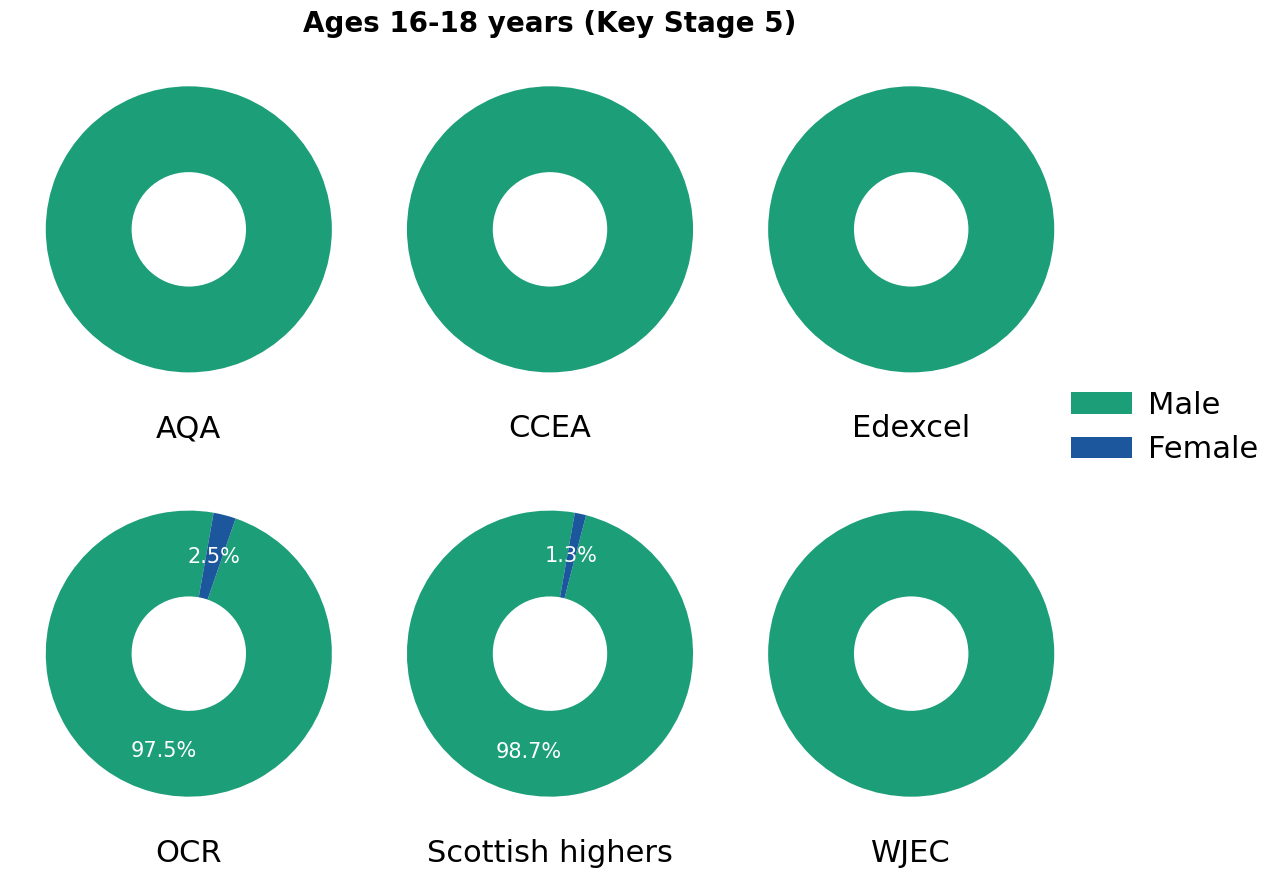

In [33]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(12, 9))
ax = ax.flatten()  # flatten to make indexing easier

for jj in range(6):
    m = dataset[EXAMBOARDS[exam_boards[jj]]]["overall"]["unique"]["male"]
    f = dataset[EXAMBOARDS[exam_boards[jj]]]["overall"]["unique"]["female"]
    val = [m, f]
    if f == 0:
        ax[jj].pie(
            val, colors=[colours[1], colours[0]],
            startangle=80, wedgeprops=dict(width=.6),
        )
    else:
        ax[jj].pie(
            val, colors=[colours[1], colours[0]],
            startangle=80, wedgeprops=dict(width=.6),
            autopct='%1.1f%%', pctdistance=0.7,
            textprops={'fontsize': 15, 'color': 'white'}
        )
    
    if (exam_boards[jj] == 'Scottish_highers'):
        ax[jj].set_xlabel('Scottish Highers')
    else:
        ax[jj].set_xlabel(exam_boards[jj])

# Optional: hide any unused axes (e.g. if you ever use fewer than 6)
for kk in range(len(ax)):
    if kk >= len(exam_boards):
        ax[kk].axis('off')
        
plt.figlegend(['Male', 'Female'], bbox_to_anchor=(1.1, 0.57),#(1, 0.55)
              bbox_transform=fig.transFigure, ncol=1, borderaxespad=0.,
              handletextpad=0.5, columnspacing=1)

plt.subplots_adjust(wspace=0.01, hspace=0.1, left=0.05, right=0.95, top=0.95, bottom=0.05)

plt.suptitle('Ages 16-18 years (Key Stage 5)', fontsize=20, weight = 'bold')

plt.savefig('../Figures/summary_male_vs_female_UK_A_Level.png', dpi = 100, bbox_inches='tight')


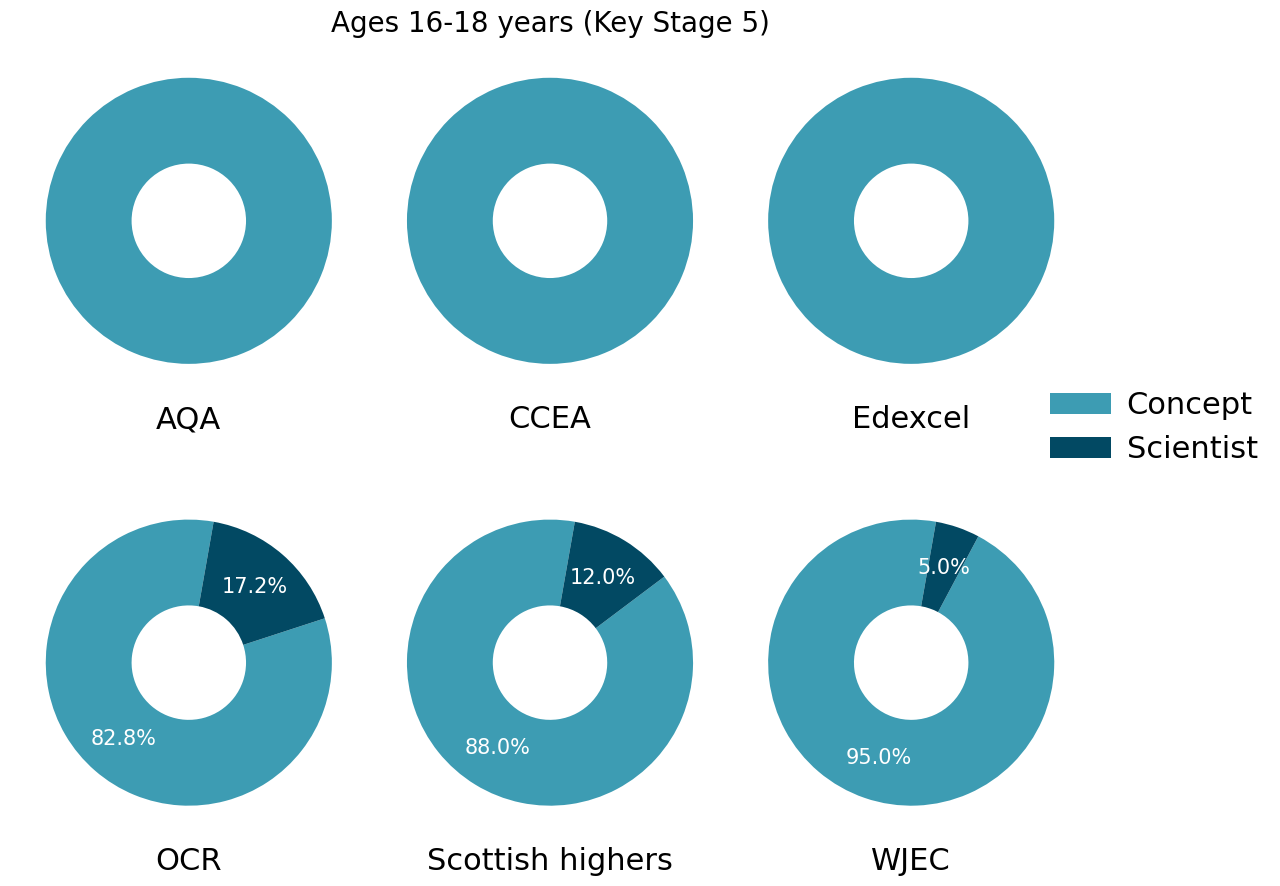

In [34]:
# Create pie charts showing scientist vs concept breakdown per exam board
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(12, 9))
ax = ax.flatten()  # Flatten to simplify iteration

for jj in range(6):  # for each exam board
    board_key = EXAMBOARDS[exam_boards[jj]]
    m1 = dataset[board_key]["overall"]["concept"]["male"]
    f1 = dataset[board_key]["overall"]["concept"]["female"]
    m2 = dataset[board_key]["overall"]["scientist"]["male"]
    f2 = dataset[board_key]["overall"]["scientist"]["female"]

    val = [m1 + f1, m2 + f2]  # [concepts, scientists]

    if m2 + f2 == 0:
        ax[jj].pie(
            val, colors=[colours[3], colours[2]],
            startangle=80, wedgeprops=dict(width=.6)
        )
    else:
        ax[jj].pie(
            val, colors=[colours[3], colours[2]],
            startangle=80, wedgeprops=dict(width=.6),
            autopct='%1.1f%%', pctdistance=0.7,
            textprops={'fontsize': 15, 'color': 'white'}
        )

    if (exam_boards[jj] == 'Scottish_highers'):
        ax[jj].set_xlabel('Scottish Highers')
    else:
        ax[jj].set_xlabel(exam_boards[jj])

# Add legend
plt.figlegend(['Concept', 'Scientist'], bbox_to_anchor=(1.1, 0.57),
              bbox_transform=fig.transFigure, ncol=1,
              borderaxespad=0., handletextpad=0.5, columnspacing=1)

# Adjust spacing
plt.subplots_adjust(wspace=0.01, hspace=0.2, left=0.05, right=0.95, top=0.95, bottom=0.05)

plt.suptitle('Ages 16-18 years (Key Stage 5)', fontsize=20)

plt.savefig('../Figures/summary_concept_vs_scientist_UK_A_Level.png', dpi = 100, bbox_inches='tight')


In [35]:
def collect_region_data(exam_boards, dataset, EXAMBOARDS):
    region_list = []
    nan_regions = set()

    for state in exam_boards:
        region_keys = dataset[EXAMBOARDS[state]]["overall"]["unique"]["region"].keys()
        for r in region_keys:
            if isinstance(r, str):
                r_clean = r.strip().title()
                if r_clean == "Eruope":
                    r_clean = "Europe"
                if r_clean.lower() == "nan":
                    nan_regions.add(r)
                else:
                    region_list.append(r_clean)
            else:
                nan_regions.add(r)

    regions = sorted(set(region_list))

    name_list = []
    region = []
    nan_regions_scientist = set()

    for state in exam_boards:
        names = list(dataset[EXAMBOARDS[state]]["names"].keys())
        for name in names:
            r = dataset[EXAMBOARDS[state]]["names"][name]["region"]
            if isinstance(r, str):
                r_clean = r.strip().title()
                if r_clean == "Eruope":
                    r_clean = "Europe"
                if r_clean.lower() == "nan":
                    nan_regions_scientist.add(r)
                else:
                    region.append(r_clean)
                    name_list.append(name)
            else:
                nan_regions_scientist.add(r)

    idx = [name_list.index(x) for x in set(name_list)]
    region_names = [region[i] for i in idx]

    vals = [region_names.count(rr) for rr in regions]
    total = sum(vals)

    def wrap_label(label, max_words=2):
        words = label.split()
        return "\n".join(
            " ".join(words[i:i + max_words])
            for i in range(0, len(words), max_words)
        )

    labels = [
        f"{wrap_label(r)}\n({v/total*100:.1f}%)"
        for r, v in zip(regions, vals)
    ]

    return regions, vals, labels

'''
Save A-level data to be plotted later
'''
regions_A, vals_A, labels_A = collect_region_data(
    exam_boards, dataset, EXAMBOARDS
)

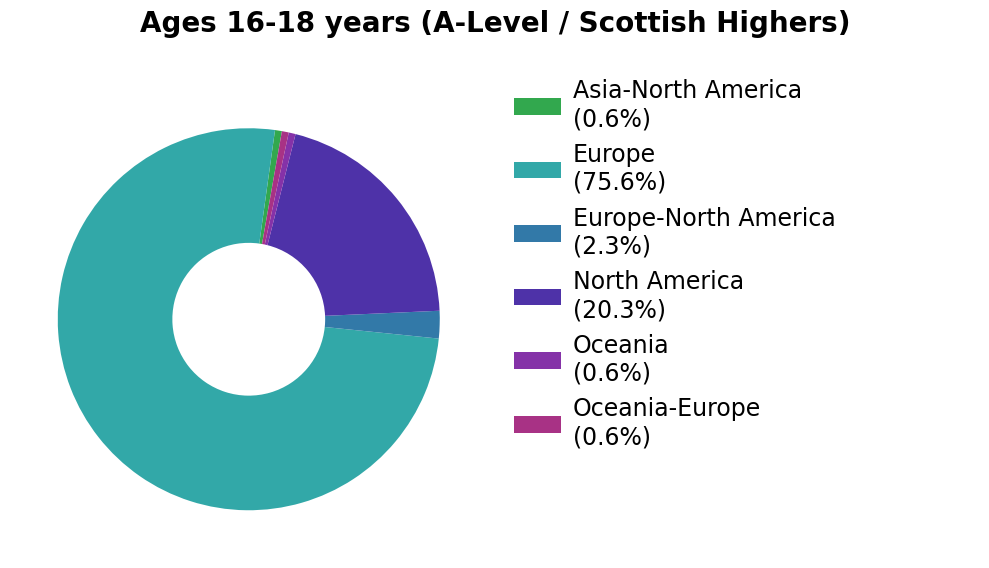

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# --- Collect and clean data ---
region_list = []
nan_regions = set()
for state in exam_boards:
    region_keys = dataset[EXAMBOARDS[state]]["overall"]["unique"]["region"].keys()
    for r in region_keys:
        if isinstance(r, str):
            r_clean = r.strip().title()
            if r_clean == "Eruope":
                r_clean = "Europe"
            if r_clean.lower() == "nan":
                nan_regions.add(r)
            else:
                region_list.append(r_clean)
        else:
            nan_regions.add(r)

# Print nan or malformed entries
if nan_regions:
    print("Excluded 'nan' or malformed region entries from 'overall':")
    for r in nan_regions:
        print(f"  - {repr(r)}")

regions = sorted(set(region_list))

# Assign colors using a qualitative palette
cmap = plt.get_cmap('Set3')

Colours = ["#32a84e", "#32a8a8", "#3279a8",
           "#4e32a8", "#8532a8", "#a83285"]



#colours = [cmap(i % cmap.N) for i in range(len(regions))]

# --- Build list of unique scientist names and regions ---
name_list = []
region = []
nan_regions_scientist = set()
for state in exam_boards:
    names = list(dataset[EXAMBOARDS[state]]["names"].keys())
    for name in names:
        r = dataset[EXAMBOARDS[state]]["names"][name]["region"]
        if isinstance(r, str):
            r_clean = r.strip().title()
            if r_clean == "Eruope":
                r_clean = "Europe"
            if r_clean.lower() == "nan":
                nan_regions_scientist.add(r)
            else:
                region.append(r_clean)
                name_list.append(name)
        else:
            nan_regions_scientist.add(r)

# Print nan or malformed entries
if nan_regions_scientist:
    print("Excluded 'nan' or malformed region entries from scientists:")
    for r in nan_regions_scientist:
        print(f"  - {repr(r)}")

# Remove duplicate scientist names (preserve first mention)
idx = [name_list.index(x) for x in set(name_list)]
unique_names = [name_list[i] for i in idx]
region_names = [region[i] for i in idx]

# Count by region
vals = [region_names.count(rr) for rr in regions]

# Format region names with percentages for the legend
total = sum(vals)
region_labels = [f"{r} ({v/total*100:.1f}%)" for r, v in zip(regions, vals)]

def wrap_label(label, max_words=2):
    words = label.split()
    lines = []
    for i in range(0, len(words), max_words):
        lines.append(" ".join(words[i:i+max_words]))
    return "\n".join(lines)

region_labels = [
    f"{wrap_label(r)}\n({v/total*100:.1f}%)" for r, v in zip(regions, vals)
]


# --- Plotting ---
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))

# Main pie chart (no % inside)
ax[0].pie(
    vals, colors=Colours, startangle=80,
    wedgeprops=dict(width=.6), textprops={'fontsize': 18, 'color': 'black'}
)

# Dummy pie chart for layout spacing
ax[1].pie(vals, colors=['white'] * len(vals))

# Legend with region names and percentages
plt.figlegend(
    region_labels,
    bbox_to_anchor=(0.85, 0.88),
    bbox_transform=fig.transFigure,
    ncol=1, borderaxespad=0., handletextpad=0.5, columnspacing=1,
    fontsize=17
)

plt.suptitle('Ages 16-18 years (A-Level / Scottish Highers)', fontsize=20, weight = 'bold')

plt.tight_layout()

plt.savefig('../Figures/summary_region_all_UK_A_Level.png',
            dpi=100,
            bbox_inches='tight')


# GCSE analysis

#### Code is essentially the same, just with different paths and files

In [37]:
import json

# Exam boards (these really are global, so keep them explicit)
exam_boards = ["AQA", "CCEA", "Edexcel", "OCR A", "OCR B", "Scottish NQ5", "WJEC"]
Exam_Boards = ["AQA", "CCEA", "Edexcel", "OCR_A", "OCR_B", "Scottish", "WJEC"]

EXAMBOARDS = {
    "AQA": "AQA",
    "CCEA": "CCEA",
    "Edexcel": "Edexcel",
    "OCR A": "OCR_A",
    "OCR B": "OCR_B",
    "Scottish NQ5": "Scottish",
    "WJEC": "WJEC",
}

# Read in the JSON files
dataset = {}
for board in exam_boards:
    path = f"../Stats/{EXAMBOARDS[board]}_SummaryStats_GCSE.json"
    with open(path, "r", encoding="utf-8") as ff:
        dataset[EXAMBOARDS[board]] = json.load(ff)

# ------------------------------------------------------------------
# Derive subjects dynamically (this is the key change)
# ------------------------------------------------------------------

# All subjects that appear in any exam board
subjects = sorted({
    sb
    for board in exam_boards
    for sb in dataset[EXAMBOARDS[board]]["subjects"].keys()
})

# Use this wherever you previously used `labels`
labels = subjects


In [38]:
# ------------------------------------------------------------
# Create a json data file with all statistics (robust version)
# ------------------------------------------------------------

def get_counts(board, subject, category):
    """Return (male, female) counts or (0, 0) if missing."""
    subj = dataset[EXAMBOARDS[board]]["subjects"].get(subject)
    if subj is None:
        return 0, 0
    cat = subj.get(category)
    if cat is None:
        return 0, 0
    return cat["male"], cat["female"]


stats_data = {}

# ------------------------------------------------------------
# Per-subject / per-category / per-board statistics
# ------------------------------------------------------------

for sb in subjects:
    stats_data[sb] = {}
    for cat in categories:
        stats_data[sb][cat] = {}
        for eb in exam_boards:
            m, f = get_counts(eb, sb, cat)
            stats_data[sb][cat][eb] = {
                "male": m,
                "female": f,
                "both": m + f
            }

# ------------------------------------------------------------
# OVERALL SECTION
# ------------------------------------------------------------

stats_data["overall"] = {
    "subjects": {},
    "exam_boards": {}
}

tot_across_boards_categories_subjects = 0
tot_across_boards_concept_subjects = 0
tot_across_boards_scientist_subjects = 0

# ------------------------------------------------------------
# Overall by subject
# ------------------------------------------------------------

for sb in subjects:
    stats_data["overall"]["subjects"][sb] = {}
    subject_total = 0

    for cat in categories:
        cat_total = sum(
            stats_data[sb][cat][eb]["both"]
            for eb in exam_boards
        )
        stats_data["overall"]["subjects"][sb][cat] = cat_total
        subject_total += cat_total

    stats_data["overall"]["subjects"][sb]["total"] = subject_total

    tot_across_boards_concept_subjects += stats_data["overall"]["subjects"][sb].get("concept", 0)
    tot_across_boards_scientist_subjects += stats_data["overall"]["subjects"][sb].get("scientist", 0)
    tot_across_boards_categories_subjects += subject_total


for sb in subjects:
    stats_data["overall"]["subjects"][sb]["% of total mentions"] = round(
        stats_data["overall"]["subjects"][sb]["total"]
        / tot_across_boards_categories_subjects * 100, 2
    )
    stats_data["overall"]["subjects"][sb]["% of total concept mentions"] = round(
        stats_data["overall"]["subjects"][sb].get("concept", 0)
        / tot_across_boards_concept_subjects * 100, 2
    )
    stats_data["overall"]["subjects"][sb]["% of total scientist mentions"] = round(
        stats_data["overall"]["subjects"][sb].get("scientist", 0)
        / tot_across_boards_scientist_subjects * 100, 2
    )

# ------------------------------------------------------------
# Overall by exam board
# ------------------------------------------------------------

tot_across_subjects_categories_boards = 0
tot_across_subjects_concept_boards = 0
tot_across_subjects_scientist_boards = 0

for eb in exam_boards:
    stats_data["overall"]["exam_boards"][eb] = {}
    board_total = 0

    for cat in categories:
        cat_total = sum(
            stats_data[sb][cat][eb]["both"]
            for sb in subjects
        )
        stats_data["overall"]["exam_boards"][eb][cat] = cat_total
        board_total += cat_total

    stats_data["overall"]["exam_boards"][eb]["total"] = board_total

    tot_across_subjects_concept_boards += stats_data["overall"]["exam_boards"][eb].get("concept", 0)
    tot_across_subjects_scientist_boards += stats_data["overall"]["exam_boards"][eb].get("scientist", 0)
    tot_across_subjects_categories_boards += board_total


for eb in exam_boards:
    stats_data["overall"]["exam_boards"][eb]["% of total mentions"] = round(
        stats_data["overall"]["exam_boards"][eb]["total"]
        / tot_across_subjects_categories_boards * 100, 2
    )
    stats_data["overall"]["exam_boards"][eb]["% of total concept mentions"] = round(
        stats_data["overall"]["exam_boards"][eb].get("concept", 0)
        / tot_across_subjects_concept_boards * 100, 2
    )
    stats_data["overall"]["exam_boards"][eb]["% of total scientist mentions"] = round(
        stats_data["overall"]["exam_boards"][eb].get("scientist", 0)
        / tot_across_subjects_scientist_boards * 100, 2
    )

# ------------------------------------------------------------
# Top-level totals
# ------------------------------------------------------------

stats_data["overall"]["total mentions"] = tot_across_boards_categories_subjects
stats_data["overall"]["total concept mentions"] = tot_across_boards_concept_subjects
stats_data["overall"]["total scientist mentions"] = tot_across_boards_scientist_subjects

# ------------------------------------------------------------
# Write out
# ------------------------------------------------------------

with open('../Stats/FullSummaryStatsUK_GCSE.json', 'w', encoding="utf-8") as fp:
    json.dump(stats_data, fp, indent=4)


# Unique scientist count and checks

In [39]:
import json
from collections import Counter, defaultdict

# ============================================================
# 1. Containers
# ============================================================

# Unique scientists across all exam boards (deduplicated by name)
global_scientists = {}

# Scientist- and concept-category mentions
scientist_mentions_by_board = defaultdict(int)
concept_mentions_by_board = defaultdict(int)

scientist_mentions_by_board_subject = defaultdict(lambda: defaultdict(int))
concept_mentions_by_board_subject = defaultdict(lambda: defaultdict(int))

# ============================================================
# 2. Parse all exam boards
# ============================================================

for board in Exam_Boards:
    path = f"../Stats/{board}_SummaryStats_GCSE.json"

    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    # ---- Count mentions by subject ----
    for subject, subject_data in data["subjects"].items():

        sci = subject_data.get("scientist", {})
        con = subject_data.get("concept", {})

        sci_mentions = sci.get("male", 0) + sci.get("female", 0)
        con_mentions = con.get("male", 0) + con.get("female", 0)

        scientist_mentions_by_board_subject[board][subject] += sci_mentions
        concept_mentions_by_board_subject[board][subject] += con_mentions

        scientist_mentions_by_board[board] += sci_mentions
        concept_mentions_by_board[board] += con_mentions

    # ---- Merge unique scientists (identity only, no category meaning) ----
    for name, info in data["names"].items():
        if name not in global_scientists:
            global_scientists[name] = {
                "gender": info.get("gender", "unknown"),
                "region": info.get("region", "unknown")
            }

# ============================================================
# 3. Global totals (correct semantics)
# ============================================================

total_unique_scientists = len(global_scientists)

total_scientist_mentions_global = sum(scientist_mentions_by_board.values())
total_concept_mentions_global = sum(concept_mentions_by_board.values())

unique_by_gender = Counter(
    s["gender"] for s in global_scientists.values()
)

unique_by_region = Counter(
    s["region"] for s in global_scientists.values()
)

# ============================================================
# 4. Reporting
# ============================================================

print("\n=== UNIQUE SCIENTISTS (GLOBAL, DEDUPLICATED ACROSS ALL EXAM BOARDS) ===")
print(f"Total unique scientists (distinct named individuals): {total_unique_scientists}")
print(f"Unique scientists by gender: {dict(unique_by_gender)}")
print(f"Unique scientists by region: {dict(unique_by_region)}")

print("\n=== TOTAL SCIENTIST-CATEGORY MENTIONS PER EXAM BOARD ===")
for board in Exam_Boards:
    print(f"{board}: {scientist_mentions_by_board[board]} scientist-category mentions")

print("\n=== TOTAL CONCEPT-CATEGORY MENTIONS PER EXAM BOARD ===")
for board in Exam_Boards:
    print(f"{board}: {concept_mentions_by_board[board]} concept-category mentions")

print("\n=== TOTAL SCIENTIST-CATEGORY MENTIONS PER EXAM BOARD AND SUBJECT ===")
for board in Exam_Boards:
    print(f"\n{board}:")
    for subject, count in scientist_mentions_by_board_subject[board].items():
        print(f"  {subject}: {count} scientist-category mentions")

print("\n=== TOTAL CONCEPT-CATEGORY MENTIONS PER EXAM BOARD AND SUBJECT ===")
for board in Exam_Boards:
    print(f"\n{board}:")
    for subject, count in concept_mentions_by_board_subject[board].items():
        print(f"  {subject}: {count} concept-category mentions")

print("\n=== GLOBAL TOTALS ACROSS ALL EXAM BOARDS ===")
print(
    "Total scientist-category mentions across all exam boards "
    f"(counting repeated mentions): {total_scientist_mentions_global}"
)
print(
    "Total concept-category mentions across all exam boards "
    f"(counting repeated mentions): {total_concept_mentions_global}"
)

# ============================================================
# 5. Consistency check (now valid)
# ============================================================

total_mentions_from_files = 0

for board in Exam_Boards:
    path = f"../Stats/{board}_SummaryStats_GCSE.json"

    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    sci = data["overall"]["scientist"]
    total_mentions_from_files += sci.get("male", 0) + sci.get("female", 0)

print("\n=== CONSISTENCY CHECK (SCIENTIST-CATEGORY MENTIONS) ===")
print(
    f"Total scientist-category mentions from per-board 'overall' sections: "
    f"{total_mentions_from_files}"
)
print(
    f"Total scientist-category mentions summed from subjects: "
    f"{total_scientist_mentions_global}"
)

if total_scientist_mentions_global == total_mentions_from_files:
    print("✔ Totals match — scientist-category aggregation is correct.")
else:
    print("✘ Totals do NOT match — investigate upstream counting.")


print("\n=== UNIQUE SCIENTIST NAMES (DEDUPLICATED ACROSS ALL EXAM BOARDS) ===")
for name in sorted(global_scientists.keys()):
    print(name)



=== UNIQUE SCIENTISTS (GLOBAL, DEDUPLICATED ACROSS ALL EXAM BOARDS) ===
Total unique scientists (distinct named individuals): 77
Unique scientists by gender: {'male': 76, 'female': 1}
Unique scientists by region: {'europe': 58, 'north america': 11, 'oceania': 2, 'africa': 2, 'asia-north america': 1, 'europe-oceania': 1, 'oceania-europe': 1, 'europe-north america': 1}

=== TOTAL SCIENTIST-CATEGORY MENTIONS PER EXAM BOARD ===
AQA: 4 scientist-category mentions
CCEA: 5 scientist-category mentions
Edexcel: 12 scientist-category mentions
OCR_A: 11 scientist-category mentions
OCR_B: 23 scientist-category mentions
Scottish: 1 scientist-category mentions
WJEC: 13 scientist-category mentions

=== TOTAL CONCEPT-CATEGORY MENTIONS PER EXAM BOARD ===
AQA: 12 concept-category mentions
CCEA: 18 concept-category mentions
Edexcel: 33 concept-category mentions
OCR_A: 18 concept-category mentions
OCR_B: 9 concept-category mentions
Scottish: 12 concept-category mentions
WJEC: 16 concept-category mentions

# Figures 

### Subjects

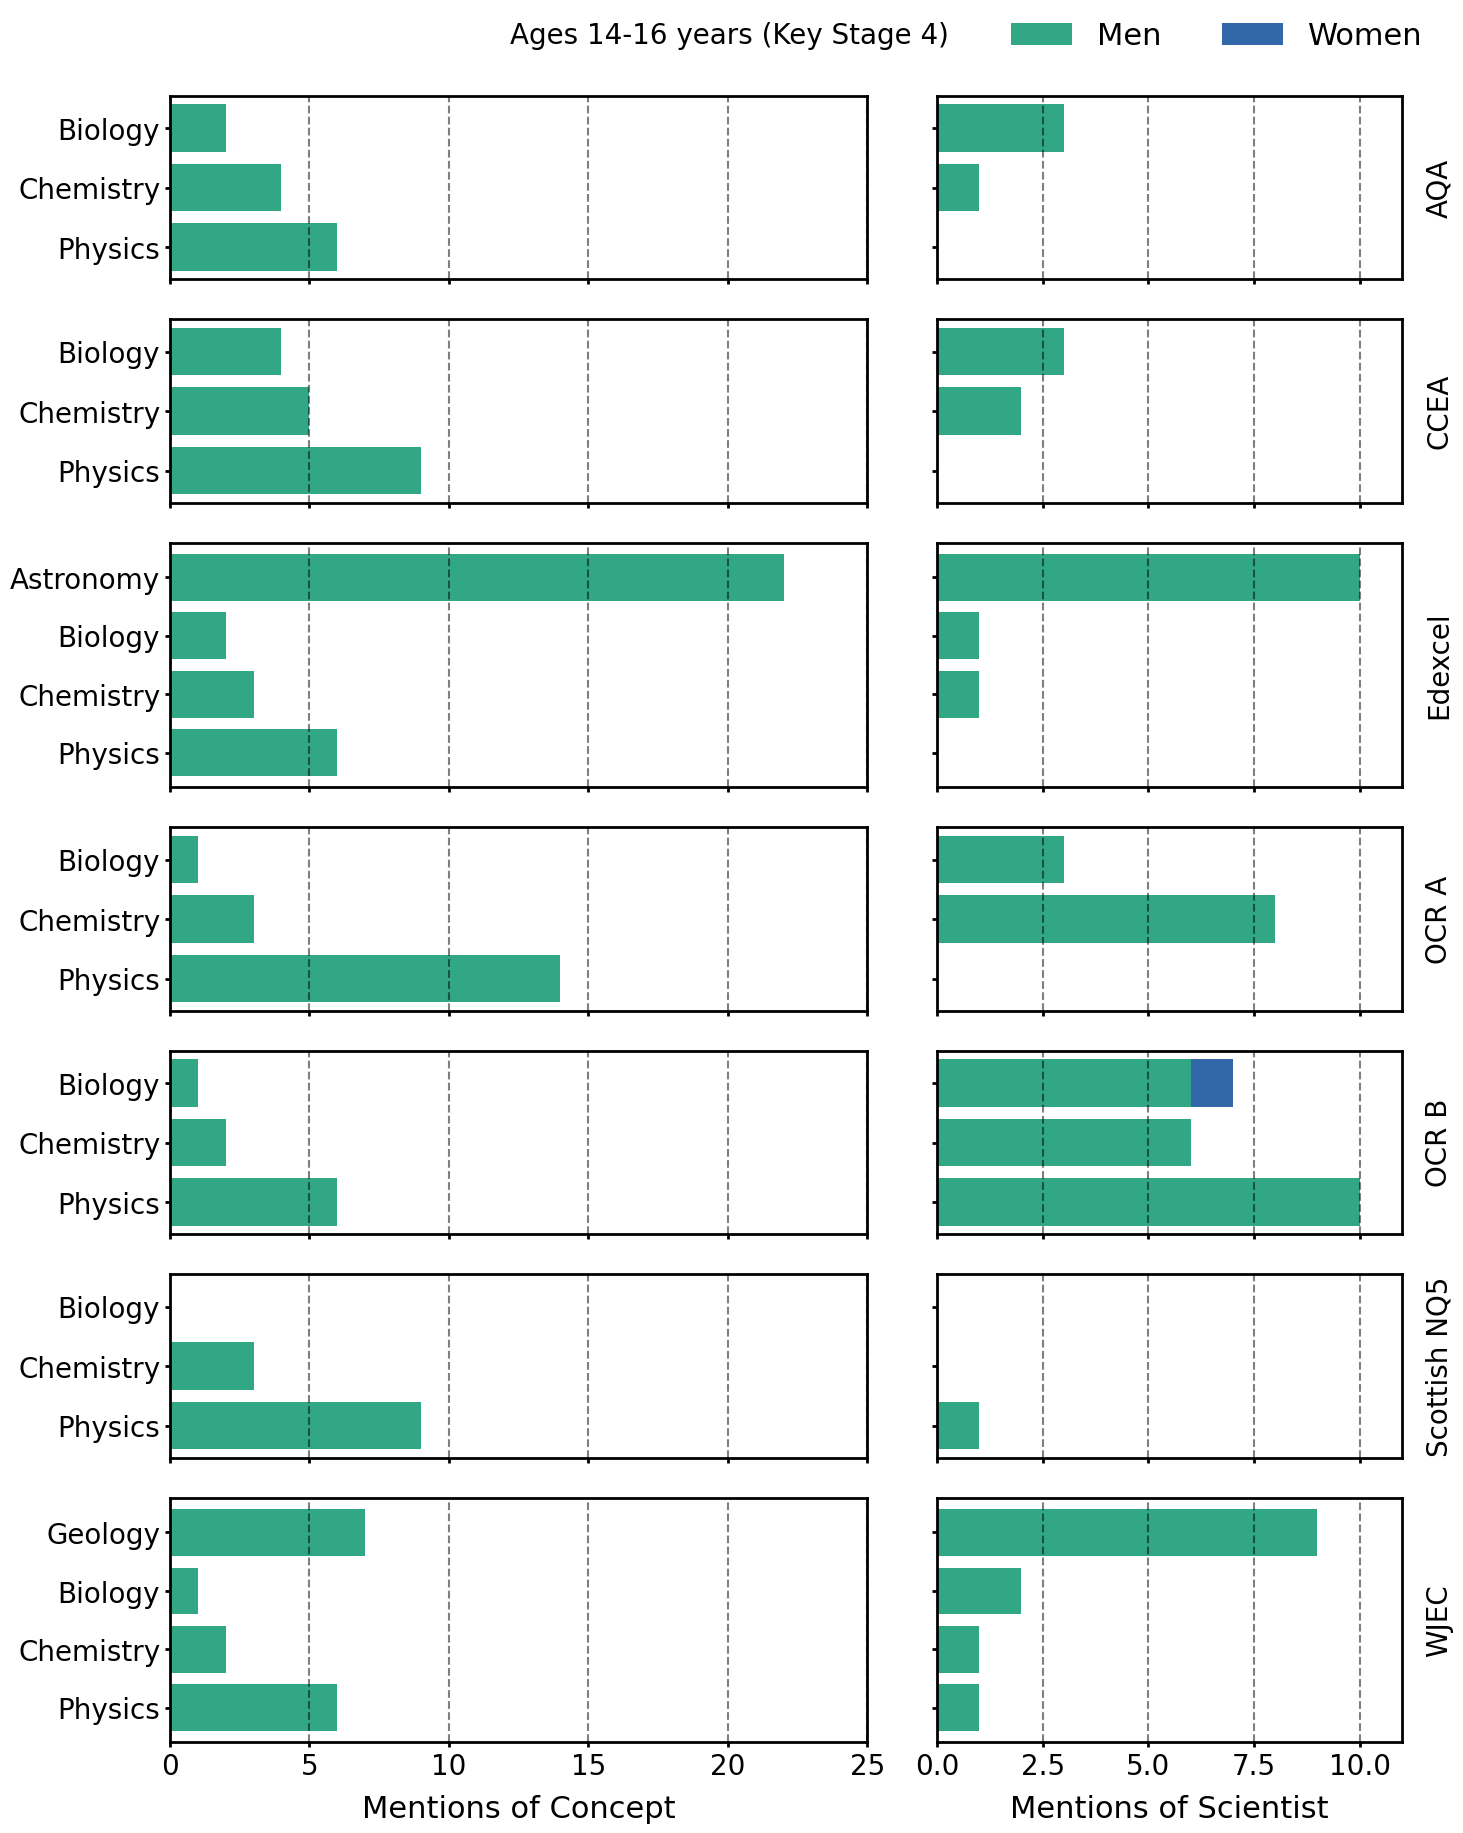

In [40]:
# ------------------------------------------------------------
# 1. Pre-calculate subjects per board to determine height ratios
# ------------------------------------------------------------
core_subjects = {"physics", "chemistry", "biology"}
subject_counts = []
subjects_by_board = []

for board in exam_boards:
    # Logic to identify which subjects are included for this specific board
    subjects_here = [
        sb for sb, data in dataset[EXAMBOARDS[board]]["subjects"].items()
        if (
            sb in core_subjects
            or (
                "concept" in data
                and (data["concept"]["male"] + data["concept"]["female"]) > 0
            )
        )
    ]
    subjects_by_board.append(subjects_here)
    subject_counts.append(len(subjects_here))

# ------------------------------------------------------------
# 2. Create figure with dynamic height and height_ratios
# ------------------------------------------------------------
# Calculate total height: e.g., 0.6 inches per bar + some padding
inches_per_bar = 0.5 
total_fig_height = sum(subject_counts) * inches_per_bar + (len(exam_boards) * 1.0)

fig, axs = plt.subplots(
    nrows=len(exam_boards),
    ncols=2,
    figsize=(16, total_fig_height),
    gridspec_kw={
        'width_ratios': [0.6, 0.4],
        'height_ratios': subject_counts  # This ensures bars have equal thickness
    }
)

# ------------------------------------------------------------
# 3. Plotting logic
# ------------------------------------------------------------
for ii, board in enumerate(exam_boards):
    subjects_here = subjects_by_board[ii]
    y = range(len(subjects_here))

    # --- Left column: concepts ---
    male_c = []
    female_c = []
    for sb in subjects_here:
        cat = dataset[EXAMBOARDS[board]]["subjects"][sb].get("concept")
        m, f = (cat["male"], cat["female"]) if cat else (0, 0)
        male_c.append(m)
        female_c.append(f)

    axs[ii, 0].barh(y, male_c, color=colours[1], alpha=0.9)
    axs[ii, 0].barh(y, female_c, left=male_c, color=colours[0], alpha=0.9)
    axs[ii, 0].set_yticks(y)
    axs[ii, 0].set_yticklabels([sb.capitalize() for sb in subjects_here])
    axs[ii, 0].set_xlim(0, 25)

    # --- Right column: scientists ---
    male_s = []
    female_s = []
    for sb in subjects_here:
        cat = dataset[EXAMBOARDS[board]]["subjects"][sb].get("scientist")
        m, f = (cat["male"], cat["female"]) if cat else (0, 0)
        male_s.append(m)
        female_s.append(f)

    axs[ii, 1].barh(y, male_s, color=colours[1], alpha=0.9)
    axs[ii, 1].barh(y, female_s, left=male_s, color=colours[0], alpha=0.9)
    axs[ii, 1].set_yticks(y)
    axs[ii, 1].set_yticklabels(subjects_here)
    axs[ii, 1].set_xlim(0, 11)
    axs[ii, 1].tick_params(labelleft=False)

    # Label board on the far right
    axs[ii, 1].text(
        1.05, 0.5,
        'Scottish NQ5' if board == 'Scottish NQ5' else board,
        rotation=90, ha='left', va='center', fontsize=20,
        transform=axs[ii, 1].transAxes
    )

    # Hide x-labels for all but the bottom row
    if ii != len(exam_boards) - 1:
        axs[ii, 0].tick_params(labelbottom=False)
        axs[ii, 1].tick_params(labelbottom=False)

# ------------------------------------------------------------
# 4. Final Formatting
# ------------------------------------------------------------
axs[-1, 0].set_xlabel("Mentions of Concept", labelpad=10)
axs[-1, 1].set_xlabel("Mentions of Scientist", labelpad=10)

plt.figlegend(['Men', 'Women'], bbox_to_anchor=(0.95, 0.995), ncol=2)
plt.suptitle('Ages 14-16 years (Key Stage 4)', fontsize=20)

for ax in axs.flat:
    ax.grid(True, axis='x', linewidth=1.5, alpha=0.5)
    ax.grid(False, axis='y')

plt.subplots_adjust(wspace=0.12, hspace=0.2, left=0.15, right=0.92, top=0.94, bottom=0.05)
plt.savefig('../Figures/summary_subjects_GCSE_UK.png', dpi=100, bbox_inches='tight')

### Male compared to female mentions

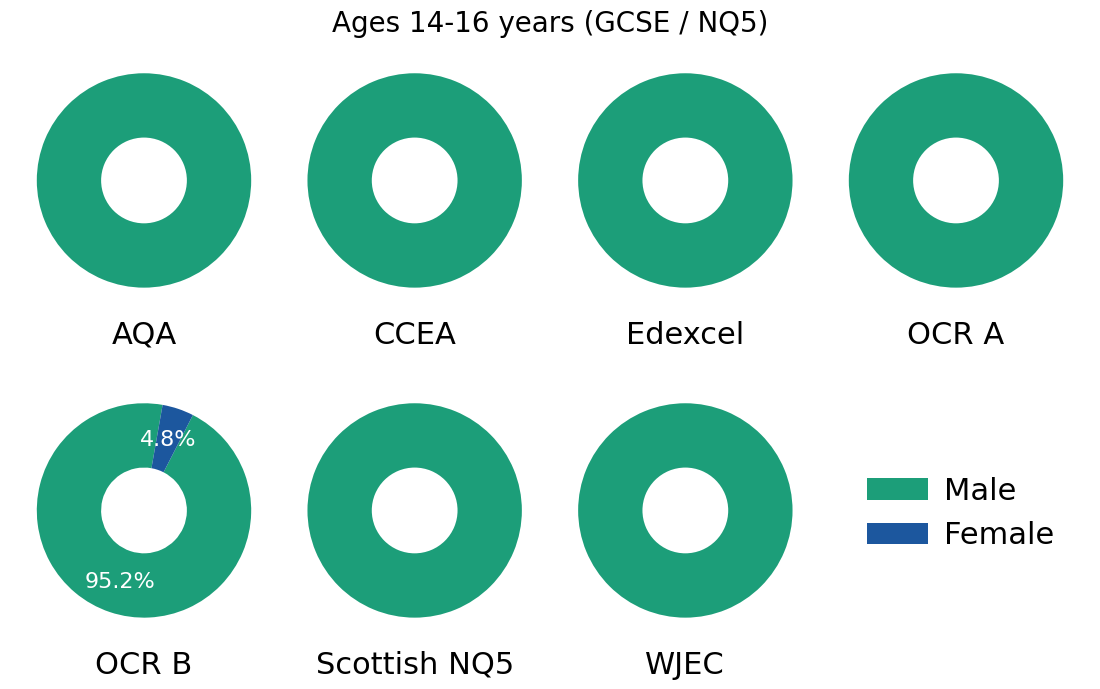

In [41]:
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(12, 7))
ax = ax.flatten()

# One pie per exam board
for jj, board in enumerate(exam_boards):
    board_key = EXAMBOARDS[board]

    m = dataset[board_key]["overall"]["unique"]["male"]
    f = dataset[board_key]["overall"]["unique"]["female"]
    val = [m, f]

    if f == 0:
        ax[jj].pie(
            val,
            colors=[colours[1], colours[0]],
            startangle=80,
            wedgeprops=dict(width=.6)
        )
    else:
        ax[jj].pie(
            val,
            colors=[colours[1], colours[0]],
            startangle=80,
            wedgeprops=dict(width=.6),
            autopct='%1.1f%%',
            pctdistance=0.7,
            textprops={'fontsize': 16, 'color': 'white'}
        )

    # Axis label
    if board == 'Scottish_highers':
        ax[jj].set_xlabel('Scottish Highers')
    else:
        ax[jj].set_xlabel(board)

# Hide unused axes
for kk in range(len(exam_boards), len(ax)):
    ax[kk].axis('off')


plt.figlegend(
    ['Male', 'Female'],
    bbox_to_anchor=(0.93, 0.33),
    bbox_transform=fig.transFigure,
    ncol=1,
    borderaxespad=0.,
    handletextpad=0.5,
    columnspacing=1
)

# Layout
plt.subplots_adjust(
    wspace=0.01,
    hspace=0.1,
    left=0.05,
    right=0.95,
    top=0.95,
    bottom=0.05
)

plt.suptitle('Ages 14-16 years (GCSE / NQ5)', fontsize=20)

plt.savefig(
    '../Figures/summary_male_vs_female_UK_GCSE.png',
    dpi=100,
    bbox_inches='tight'
)

plt.show()


### Exam boards

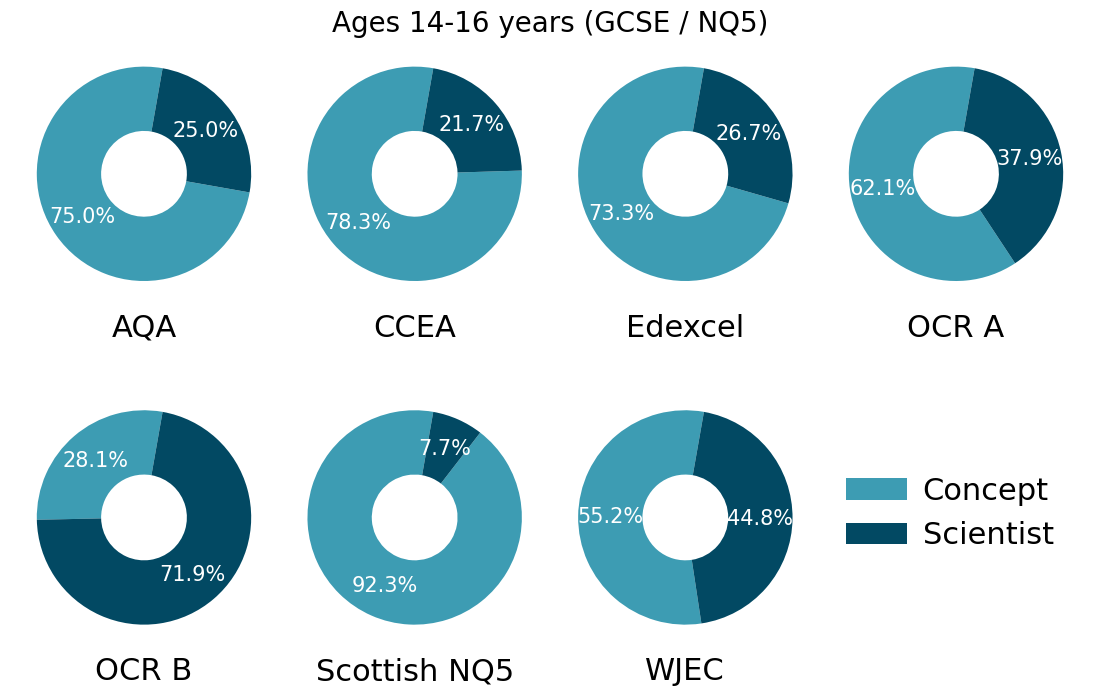

In [42]:
# Create pie charts showing scientist vs concept breakdown per exam board
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(12, 7))
ax = ax.flatten()  # Flatten to simplify iteration

# Plot one pie per exam board
for jj, board in enumerate(exam_boards):
    board_key = EXAMBOARDS[board]

    m1 = dataset[board_key]["overall"]["concept"]["male"]
    f1 = dataset[board_key]["overall"]["concept"]["female"]
    m2 = dataset[board_key]["overall"]["scientist"]["male"]
    f2 = dataset[board_key]["overall"]["scientist"]["female"]

    val = [m1 + f1, m2 + f2]  # [concepts, scientists]

    if m2 + f2 == 0:
        ax[jj].pie(
            val,
            colors=[colours[3], colours[2]],
            startangle=80,
            wedgeprops=dict(width=.6)
        )
    else:
        ax[jj].pie(
            val,
            colors=[colours[3], colours[2]],
            startangle=80,
            wedgeprops=dict(width=.6),
            autopct='%1.1f%%',
            pctdistance=0.7,
            textprops={'fontsize': 15, 'color': 'white'}
        )

    # Axis label
    if board == 'Scottish_highers':
        ax[jj].set_xlabel('Scottish Highers')
    else:
        ax[jj].set_xlabel(board)

# Hide unused axes (only the 8th subplot)
for kk in range(len(exam_boards), len(ax)):
    ax[kk].axis('off')

# Legend
plt.figlegend(
    ['Concept', 'Scientist'],
    bbox_to_anchor=(0.93, 0.33),
    bbox_transform=fig.transFigure,
    ncol=1,
    borderaxespad=0.,
    handletextpad=0.5,
    columnspacing=1
)

# Layout adjustments
plt.subplots_adjust(
    wspace=0.01,
    hspace=0.2,
    left=0.05,
    right=0.95,
    top=0.95,
    bottom=0.05
)

plt.suptitle('Ages 14-16 years (GCSE / NQ5)', fontsize=20)

plt.savefig(
    '../Figures/summary_concept_vs_scientist_UK_GCSE.png',
    dpi=100,
    bbox_inches='tight'
)

plt.show()


### Regions of the world

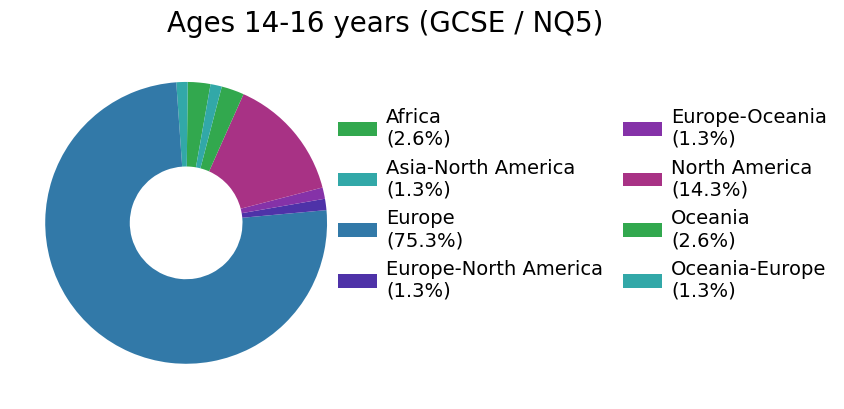

In [43]:
import matplotlib.pyplot as plt
import numpy as np

regions_G, vals_G, labels_G = collect_region_data(
    exam_boards, dataset, EXAMBOARDS
)

# --- Collect and clean data ---
region_list = []
nan_regions = set()
for state in exam_boards:
    region_keys = dataset[EXAMBOARDS[state]]["overall"]["unique"]["region"].keys()
    for r in region_keys:
        if isinstance(r, str):
            r_clean = r.strip().title()
            if r_clean == "Eruope":
                r_clean = "Europe"
            if r_clean.lower() == "nan":
                nan_regions.add(r)
            else:
                region_list.append(r_clean)
        else:
            nan_regions.add(r)

# Print nan or malformed entries
if nan_regions:
    print("Excluded 'nan' or malformed region entries from 'overall':")
    for r in nan_regions:
        print(f"  - {repr(r)}")

regions = sorted(set(region_list))

# Assign colors using a qualitative palette
cmap = plt.get_cmap('Set3')

Colours = ["#32a84e", "#32a8a8", "#3279a8",
           "#4e32a8", "#8532a8", "#a83285"]



#colours = [cmap(i % cmap.N) for i in range(len(regions))]

# --- Build list of unique scientist names and regions ---
name_list = []
region = []
nan_regions_scientist = set()
for state in exam_boards:
    names = list(dataset[EXAMBOARDS[state]]["names"].keys())
    for name in names:
        r = dataset[EXAMBOARDS[state]]["names"][name]["region"]
        if isinstance(r, str):
            r_clean = r.strip().title()
            if r_clean == "Eruope":
                r_clean = "Europe"
            if r_clean.lower() == "nan":
                nan_regions_scientist.add(r)
            else:
                region.append(r_clean)
                name_list.append(name)
        else:
            nan_regions_scientist.add(r)

# Print nan or malformed entries
if nan_regions_scientist:
    print("Excluded 'nan' or malformed region entries from scientists:")
    for r in nan_regions_scientist:
        print(f"  - {repr(r)}")

# Remove duplicate scientist names (preserve first mention)
idx = [name_list.index(x) for x in set(name_list)]
unique_names = [name_list[i] for i in idx]
region_names = [region[i] for i in idx]

# Count by region
vals = [region_names.count(rr) for rr in regions]

# Format region names with percentages for the legend
total = sum(vals)
region_labels = [f"{r} ({v/total*100:.1f}%)" for r, v in zip(regions, vals)]

def wrap_label(label, max_words=2):
    words = label.split()
    lines = []
    for i in range(0, len(words), max_words):
        lines.append(" ".join(words[i:i+max_words]))
    return "\n".join(lines)

region_labels = [
    f"{wrap_label(r)}\n({v/total*100:.1f}%)" for r, v in zip(regions, vals)
]


# --- Plotting ---
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))

# Main pie chart (no % inside)
ax[0].pie(
    vals, colors=Colours, startangle=80,
    wedgeprops=dict(width=.6), textprops={'fontsize': 18, 'color': 'black'}
)

# Dummy pie chart for layout spacing
ax[1].pie(vals, colors=['white'] * len(vals))

# Legend with region names and percentages
plt.figlegend(
    region_labels,
    bbox_to_anchor=(0.95, 0.7),
    bbox_transform=fig.transFigure,
    ncol=2, borderaxespad=0., handletextpad=0.5, columnspacing=1,
    fontsize=14
)

plt.suptitle('Ages 14-16 years (GCSE / NQ5)', fontsize=20, y = 0.85)#, weight = 'bold')


plt.savefig('../Figures/summary_region_all_UK_GCSE.png',
            dpi=100,
            bbox_inches='tight')


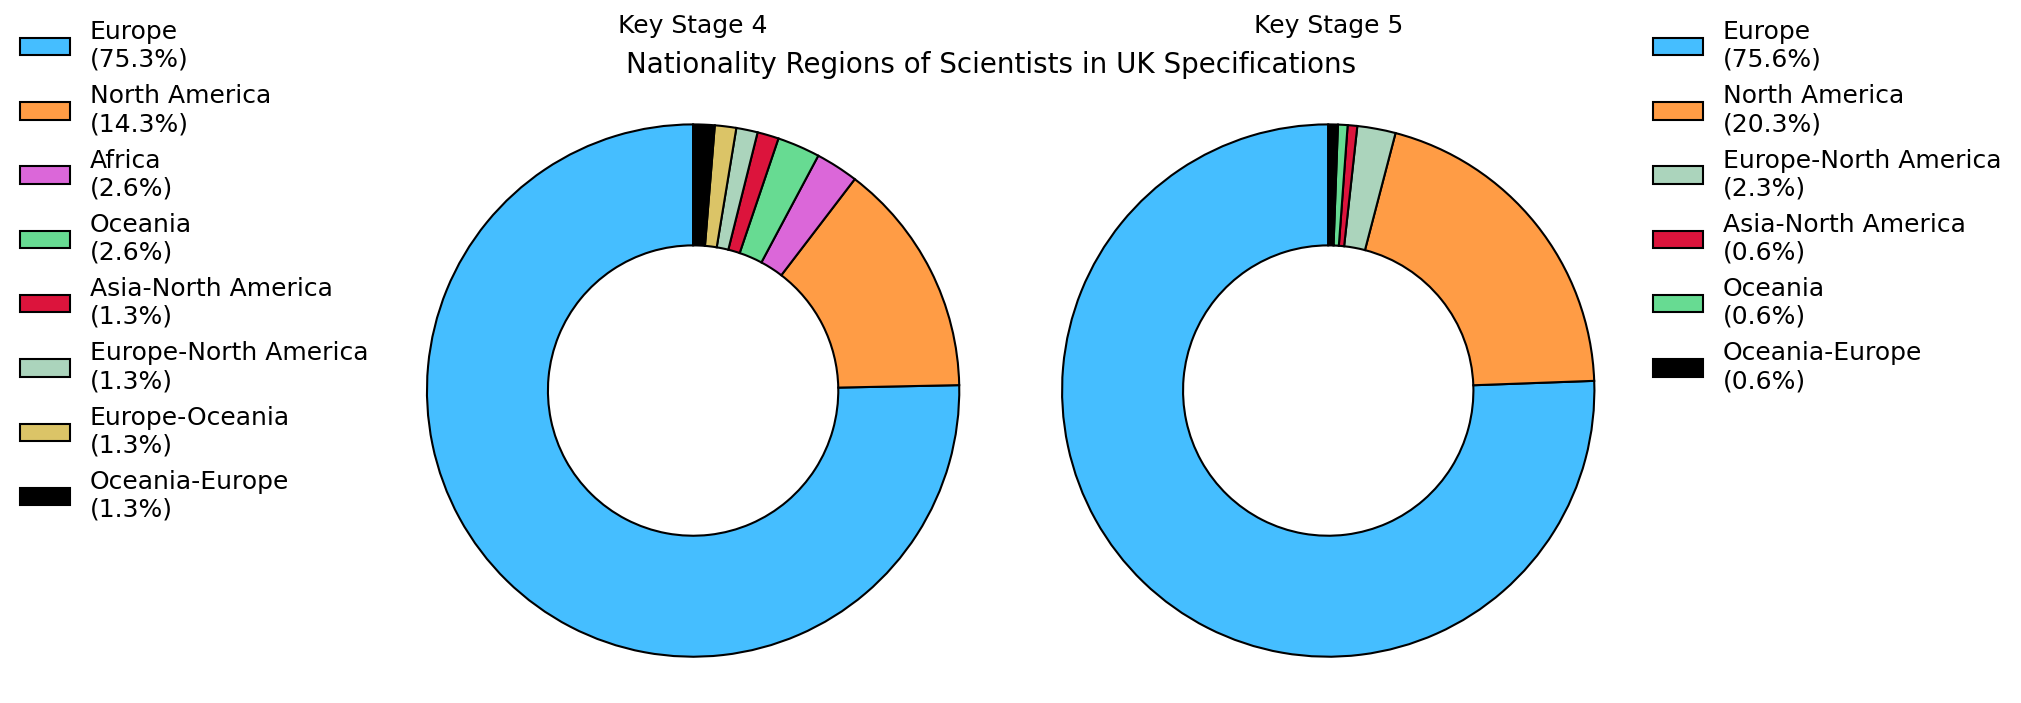

In [44]:
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Setup Colours & Mapping
# ------------------------------------------------------------
cmap = plt.get_cmap('Set2_r') 
COLOURS = [cmap(i) for i in range(10)]

COLOURS = ["#db67d9", "crimson", "#45beff",
           "#abd4bc", "#dbc467", "#ff9c45", '#67db92', 'k']

all_regions = sorted(set(regions_G) | set(regions_A))
region_colour_map = dict(zip(all_regions, COLOURS))

# ------------------------------------------------------------
# 2. Sort and Map Data
# ------------------------------------------------------------
data_G = sorted(zip(vals_G, labels_G, regions_G), key=lambda x: x[0], reverse=True)
vals_G, labels_G, regions_G = zip(*data_G)
colours_G = [region_colour_map[r] for r in regions_G]

data_A = sorted(zip(vals_A, labels_A, regions_A), key=lambda x: x[0], reverse=True)
vals_A, labels_A, regions_A = zip(*data_A)
colours_A = [region_colour_map[r] for r in regions_A]

# ------------------------------------------------------------
# 3. Figure layout
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# Adjust wspace to reduce the gap between the two circles (0 is no gap)
plt.subplots_adjust(wspace=0.05) 

# Define common wedge properties
wp = {'width': 0.5, 'edgecolor': 'black', 'linewidth': 1.5}

# LEFT: Key Stage 4
wedges_G, _ = ax[0].pie(
    vals_G,
    colors=colours_G,
    startangle=90,
    radius=1.1,           # Increased from 1 to 1.3
    wedgeprops=wp,
    textprops={"fontsize": 18}
)
ax[0].set_title("Key Stage 4", fontsize=18, pad=40)

# RIGHT: Key Stage 5
wedges_A, _ = ax[1].pie(
    vals_A,
    colors=colours_A,
    startangle=90,
    radius=1.1,           # Increased from 1 to 1.3
    wedgeprops=wp,
    textprops={"fontsize": 18}
)
ax[1].set_title("Key Stage 5", fontsize=18, pad=40)

# ------------------------------------------------------------
# 4. Legends (Adjusted bbox_to_anchor for the larger circles)
# ------------------------------------------------------------
ax[0].legend(
    wedges_G, labels_G,
    loc="upper left",
    bbox_to_anchor=(-0.65, 1.15),
    fontsize=18,
    frameon=False
)

ax[1].legend(
    wedges_A, labels_A,
    loc="upper right",
    bbox_to_anchor=(1.65, 1.15),
    fontsize=18,
    frameon=False
)

# ------------------------------------------------------------
# 5. Final Styling
# ------------------------------------------------------------
fig.suptitle(
    "Nationality Regions of Scientists in UK Specifications",
    fontsize=20,
    y=0.92  # Lifted title slightly to make room for bigger circles
)

# Use bbox_inches="tight" to ensure legends aren't cut off
plt.savefig(
    "/Users/gregcooke/IncludeHerUK/Figures/summary_region_all_UK_combined.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

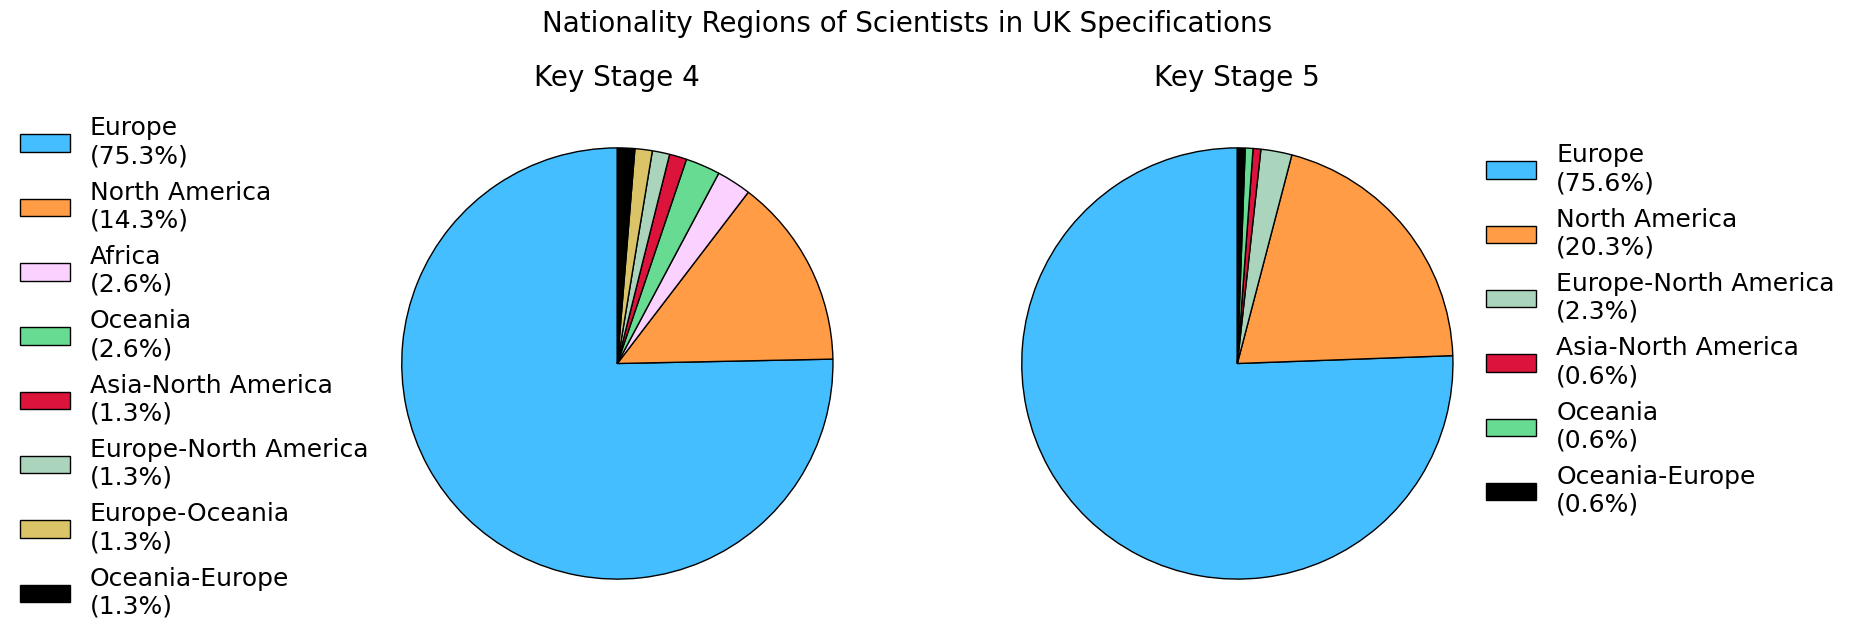

In [45]:

# ------------------------------------------------------------
# 1. Setup Colours & Mapping
# ------------------------------------------------------------
cmap = plt.get_cmap('Set2') 
COLOURS = [cmap(i) for i in range(10)]

COLOURS = ["#db67d9", "#32a8a8", "#679bdb",
           "#abd4bc", "#dbc467", "#db7767", '#67db92', 'k']

#Asia
#Asia-North America
#Africa

COLOURS = ["#fad1ff", "crimson", "#45beff",
           "#abd4bc", "#dbc467", "#ff9c45", '#67db92', 'k']
#COLOURS = ["#fad1ff", "crimson", "lightcoral",
 #          "#abd4bc", "#dbc467", "k", '#67db92', '#45beff']

all_regions = sorted(set(regions_G) | set(regions_A))
region_colour_map = dict(zip(all_regions, COLOURS))

# ------------------------------------------------------------
# 2. Sort and Map Data
# ------------------------------------------------------------
data_G = sorted(zip(vals_G, labels_G, regions_G), key=lambda x: x[0], reverse=True)
vals_G, labels_G, regions_G = zip(*data_G)
colours_G = [region_colour_map[r] for r in regions_G]

data_A = sorted(zip(vals_A, labels_A, regions_A), key=lambda x: x[0], reverse=True)
vals_A, labels_A, regions_A = zip(*data_A)
colours_A = [region_colour_map[r] for r in regions_A]

# ------------------------------------------------------------
# 3. Figure layout
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Adjust wspace to reduce the gap between the two circles
plt.subplots_adjust(wspace=0) 

# REMOVED 'width': 0.5 to make them solid circles
wp = {'edgecolor': 'black', 'linewidth': 1}

# LEFT: Key Stage 4
wedges_G, _ = ax[0].pie(
    vals_G,
    colors=colours_G,
    startangle=90,
    radius=1,
    wedgeprops=wp, # Now draws full slices
    textprops={"fontsize": 15}
)
ax[0].set_title("Key Stage 4", fontsize=20)

# RIGHT: Key Stage 5
wedges_A, _ = ax[1].pie(
    vals_A,
    colors=colours_A,
    startangle=90,
    radius=1,
    wedgeprops=wp, # Now draws full slices
    textprops={"fontsize": 15}
)
ax[1].set_title("Key Stage 5", fontsize=20)
# ------------------------------------------------------------
# 4. Legends (Adjusted bbox_to_anchor for the larger circles)
# ------------------------------------------------------------
ax[0].legend(
    wedges_G, labels_G,
    loc="upper left",
    bbox_to_anchor=(-0.65, 1),
    fontsize=18,
    frameon=False
)

ax[1].legend(
    wedges_A, labels_A,
    loc="upper right",
    bbox_to_anchor=(1.65, 0.95),
    fontsize=18,
    frameon=False
)

# ------------------------------------------------------------
# 5. Final Styling
# ------------------------------------------------------------
fig.suptitle(
    "Nationality Regions of Scientists in UK Specifications",
    fontsize=20,
    y=1  # Lifted title slightly to make room for bigger circles
)

# Use bbox_inches="tight" to ensure legends aren't cut off
plt.savefig(
    "/Users/gregcooke/IncludeHerUK/Figures/summary_region_all_UK_combined.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()